<a href="https://colab.research.google.com/github/SARANYA-SIMBHA/E-Commerce-Return-Rate-Investigation/blob/main/task_1_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#load dataset
ds=pd.read_csv("/content/book.csv")
ds.columns = ds.columns.str.strip()

In [ ]:
#head
ds.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Customer Rating,Discount percent,delivery duration,category
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12-01-2010 08:26,2.55,17850,United Kingdom,5,20,3,home decor
1,536365,71053,WHITE METAL LANTERN,6,12-01-2010 08:26,3.39,17850,United Kingdom,7,10,3,home decor
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12-01-2010 08:26,2.75,17850,United Kingdom,8,30,3,kitchenware
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12-01-2010 08:26,3.39,17850,United Kingdom,6,40,3,gifts&decor
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12-01-2010 08:26,3.39,17850,United Kingdom,5,50,3,home decor


In [ ]:
#dimension
ds.shape

(99, 12)

In [ ]:
print("\n missing values:")
print(ds.isnull().sum())
print("\n duplicate rows:")
print(ds.duplicated().sum())


 missing values:
InvoiceNo            0
StockCode            0
Description          0
Quantity             0
InvoiceDate          0
UnitPrice            0
CustomerID           0
Country              0
Customer Rating      0
Discount percent     0
delivery duration    0
category             0
dtype: int64

 duplicate rows:
0


In [ ]:
total_orders = len(ds)
returned_orders = (ds['Quantity'] < 0).sum()

return_percentage = (returned_orders / total_orders) * 100

print("\nTotal Orders:", total_orders)
print("Returned Orders:", returned_orders)
print("Return Percentage:", round(return_percentage,4), "%")


Total Orders: 99
Returned Orders: 12
Return Percentage: 12.1212 %


In [ ]:
#statistics
print("\n Product Price Statistics ")
print(ds['UnitPrice'].describe())


 Product Price Statistics 
count    99.000000
mean      3.303939
std       2.609793
min       0.420000
25%       1.770000
50%       2.750000
75%       4.250000
max      18.000000
Name: UnitPrice, dtype: float64


In [ ]:
from numpy import median
print("\n avg delivery duration")
print(ds['delivery duration'].mean())

print("\n med product price")
print(ds['UnitPrice'].median())

print("\n avg customer rating")
print(ds['Customer Rating'].mean())


 avg delivery duration
4.111111111111111

 med product price
2.75

 avg customer rating
7.070707070707071


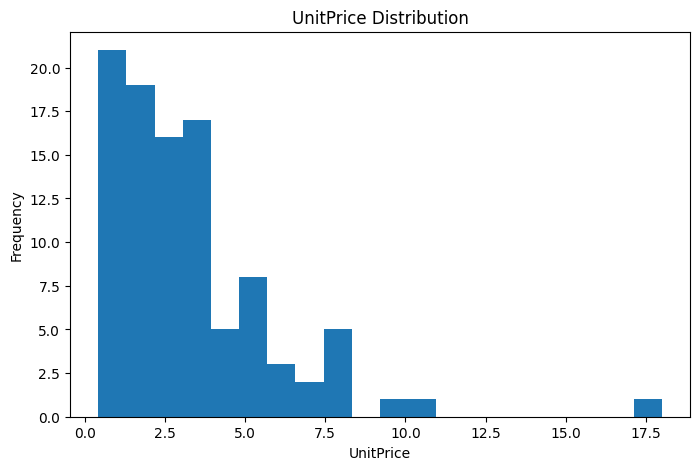

In [ ]:
from matplotlib import pyplot as plt
# Histogram
plt.figure(figsize=(8,5))
plt.hist(ds['UnitPrice'], bins=20)
plt.title("UnitPrice Distribution")
plt.xlabel("UnitPrice")
plt.ylabel("Frequency")
plt.show()

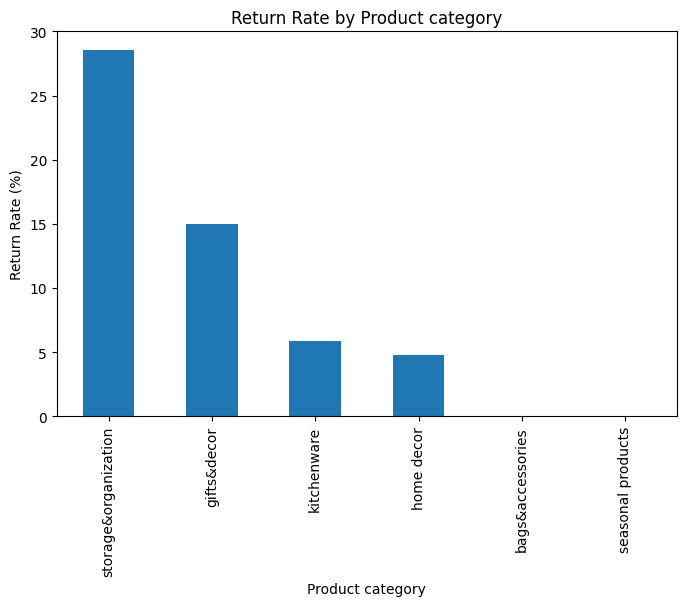

In [ ]:
#Category vs Return Rate
plt.figure(figsize=(8,5))
category_return = ds.groupby('category')['Quantity'].apply(lambda x: (x < 0).sum() / len(x) * 100)
category_return.sort_values(ascending=False).plot(kind='bar')
plt.title("Return Rate by Product category")
plt.xlabel("Product category")
plt.ylabel("Return Rate (%)")
plt.show()

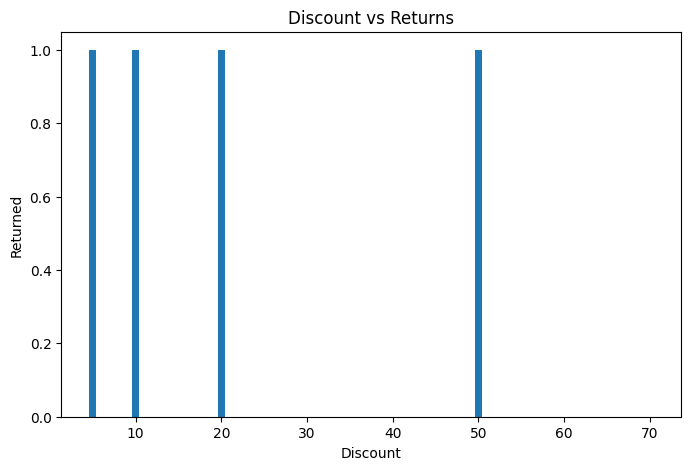

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
ds['Returned'] = (ds['Quantity'] < 0).astype(int)
plt.bar(ds['Discount percent'], ds['Returned'])
plt.xlabel('Discount')
plt.ylabel('Returned')
plt.title('Discount vs Returns')
plt.show()

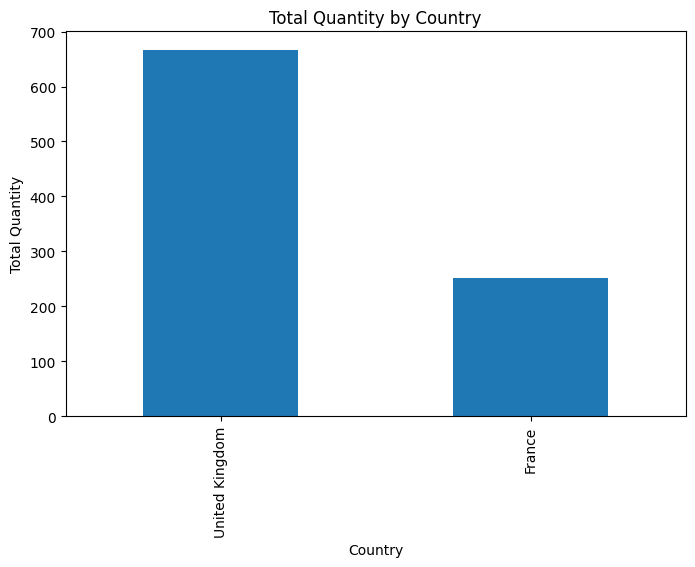

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
# Aggregate 'Quantity' by 'Country' and then sort
country_total_quantity = ds.groupby('Country')['Quantity'].sum().sort_values(ascending=False)
country_total_quantity.plot(kind='bar')
plt.xlabel('Country')
plt.ylabel('Total Quantity')
plt.title('Total Quantity by Country')
plt.show()

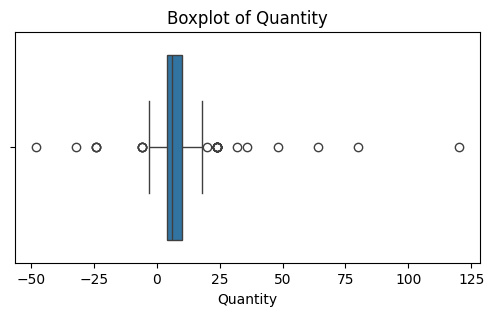

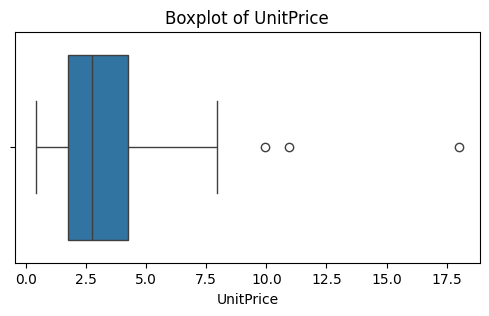

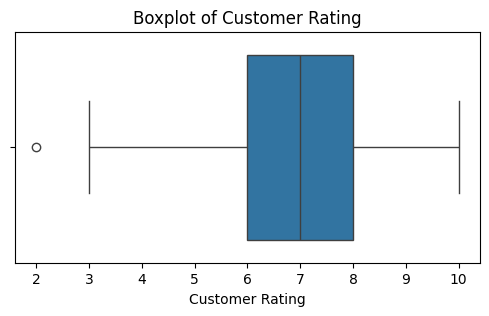

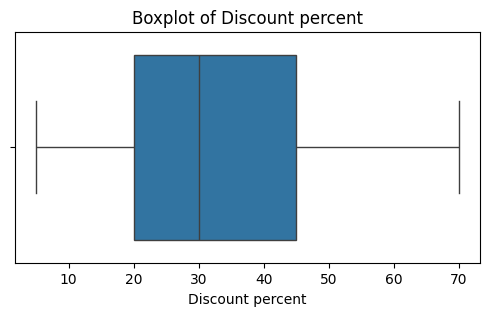

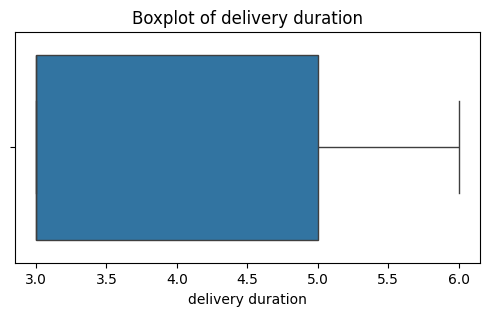

In [ ]:
#outlier using boxplot
import seaborn as sns
cols = ['Quantity','UnitPrice','Customer Rating',
        'Discount percent','delivery duration']

for col in cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=ds[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
#outlier using iqr
Q1 = ds['delivery duration'].quantile(0.25)
Q3 = ds['delivery duration'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
delivery_outliers = ds[(ds['delivery duration'] >3) | (ds['delivery duration'] > upper)]
print("Delayed Delivery Outliers")
print(delivery_outliers)

Delayed Delivery Outliers
    InvoiceNo StockCode                          Description  Quantity  \
5      536365     22752         SET 7 BABUSHKA NESTING BOXES         2   
6      536365     21730    GLASS STAR FROSTED T-LIGHT HOLDER         6   
7      536366     22633               HAND WARMER UNION JACK        -6   
8      536366     22632            HAND WARMER RED POLKA DOT         6   
10     536367     22745           POPPY'S PLAYHOUSE BEDROOM          6   
13     536367     22310              IVORY KNITTED MUG COSY          6   
15     536367     22623        BOX OF VINTAGE JIGSAW BLOCKS         -3   
17     536367     21754             HOME BUILDING BLOCK WORD         3   
19     536367     21777          RECIPE BOX WITH METAL HEART         4   
21     536368     22960             JAM MAKING SET WITH JARS        -6   
22     536368     22913          RED COAT RACK PARIS FASHION         3   
26     536370     22728            ALARM CLOCK BAKELIKE PINK        24   
27     53637

In [ ]:
Q1 = ds['UnitPrice'].quantile(0.25)
Q3 = ds['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
price_outliers = ds[(ds['UnitPrice'] < lower) | (ds['UnitPrice'] > upper)]
print("High Price Outliers")
print(price_outliers)

High Price Outliers
    InvoiceNo StockCode                     Description  Quantity  \
16     536367     22622  BOX OF VINTAGE ALPHABET BLOCKS         2   
45     536370      POST                         POSTAGE        -3   
65     536374     21258      VICTORIAN SEWING BOX LARGE       -32   

         InvoiceDate  UnitPrice  CustomerID         Country  Customer Rating  \
16  12-01-2010 08:34       9.95       13047  United Kingdom                5   
45  12-01-2010 08:45      18.00       12583          France                4   
65  12-01-2010 09:09      10.95       15100  United Kingdom                5   

    Discount percent  delivery duration              category  Returned  
16                30                  3  storage&organization         0  
45                 5                  3           gifts&decor         1  
65                50                  3  storage&organization         1  


In [ ]:
#outlier using ztest
from scipy.stats import zscore
ds['Delivery_Zscore'] = zscore(ds['delivery duration'])
delivery_z_outliers = ds[abs(ds['Delivery_Zscore']) > 3]
print(delivery_z_outliers)

Empty DataFrame
Columns: [InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country, Customer Rating, Discount percent, delivery duration, category, Returned, Delivery_Zscore]
Index: []


In [ ]:
ds['Price_Zscore'] = zscore(ds['UnitPrice'])
price_z_outliers = ds[abs(ds['Price_Zscore']) > 3]
print(price_z_outliers)

    InvoiceNo StockCode Description  Quantity       InvoiceDate  UnitPrice  \
45     536370      POST     POSTAGE        -3  12-01-2010 08:45       18.0   

    CustomerID Country  Customer Rating  Discount percent  delivery duration  \
45       12583  France                4                 5                  3   

       category  Returned  Delivery_Zscore  Price_Zscore  
45  gifts&decor         1        -0.897369      5.659778  


In [ ]:
#hypothesis testing
from scipy.stats import ttest_ind

ds['Returned'] = ds['Quantity'].apply(lambda x: 1 if x < 0 else 0)
returned_orders = ds[ds['Returned'] == 1]['delivery duration']
not_returned_orders = ds[ds['Returned'] == 0]['delivery duration']
t_stat, p_value = ttest_ind(returned_orders,not_returned_orders,equal_var=False)
print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05
if p_value < alpha:
    print("Reject H0")
    print("Delivery delay significantly impacts return behavior.")
else:
    print("Fail to Reject H0")
    print("No significant relationship found.")

T-statistic: 0.5818441558693362
P-value: 0.5704086084139607
Fail to Reject H0
No significant relationship found.


In [ ]:
# Customer Segmentation

ds['Returned'] = (ds['Quantity'] < 0).astype(int)

customer_returns = ds.groupby('CustomerID')['Returned'].sum()

high_return_customers = customer_returns[customer_returns >= 3]

print("High Return Customers:")
print(high_return_customers.sort_values(ascending=False).head(10))

premium_customers = ds[ds['UnitPrice'] > ds['UnitPrice'].quantile(0.75)]
print("\nPremium Customers Count:",
      premium_customers['CustomerID'].nunique())

High Return Customers:
CustomerID
12583    4
17850    4
Name: Returned, dtype: int64

Premium Customers Count: 4


In [ ]:
#which categories contribute most to returns
category_returns = ds[ds['Quantity'] < 0].groupby('category').size()

print("Categories with Highest Returns:")
print(category_returns.sort_values(ascending=False).head())

Categories with Highest Returns:
category
gifts&decor             6
storage&organization    4
home decor              1
kitchenware             1
dtype: int64


In [ ]:
#does delayed delivery increase return probability
returned_avg_delay = ds[(ds['Quantity'] < 0) & (ds['delivery duration']>3)]['delivery duration'].mean()

non_returned_avg_delay = ds[(ds['Quantity'] > 0) & (ds['delivery duration']<=3)]['delivery duration'].mean()

print("Average Delay (Returned Orders):", returned_avg_delay)
print("Average Delay (Non-Returned Orders):", non_returned_avg_delay)

Average Delay (Returned Orders): 5.666666666666667
Average Delay (Non-Returned Orders): 3.0


In [ ]:
#which factors are most related to returns
ds['Returned'] = (ds['Quantity'] < 0).astype(int)

corr = ds[['Returned',
           'UnitPrice',
           'Discount percent',
           'delivery duration',
           'Customer Rating']].corr()

print(corr['Returned'].sort_values(ascending=False))

Returned             1.000000
UnitPrice            0.163922
delivery duration    0.066655
Discount percent    -0.395241
Customer Rating     -0.577404
Name: Returned, dtype: float64


In [ ]:
#which customer groups need intervention
customer_returns = ds.groupby('CustomerID')['Returned'].sum()

high_return_customers = customer_returns.sort_values(
    ascending=False
).head(10)

print("Customers Needing Attention:")
print(high_return_customers)

Customers Needing Attention:
CustomerID
12583    4
17850    4
13047    2
15100    1
14688    1
13748    0
15291    0
Name: Returned, dtype: int64


Customer Rating
2     0.000000
3     0.500000
4     0.833333
5     0.500000
6     0.000000
7     0.000000
8     0.000000
9     0.000000
10    0.000000
Name: Returned, dtype: float64


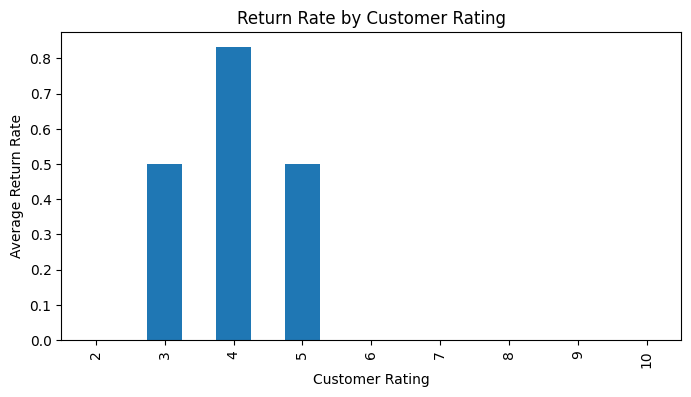

In [ ]:
#customer rating can help identify dissatisfaction before returns occurs

ds['Returned'] = (ds['Quantity'] < 0).astype(int)

rating_returns = ds.groupby('Customer Rating')['Returned'].mean()

print(rating_returns)

rating_returns.plot(
    kind='bar',
    figsize=(8,4),
    title='Return Rate by Customer Rating'
)

plt.ylabel('Average Return Rate')
plt.show()

In [ ]:
#Average rating of returned vs non returned orders
returned_rating = ds[ds['Returned']==1]['Customer Rating'].mean()

not_returned_rating = ds[ds['Returned']==0]['Customer Rating'].mean()

print("Average Rating (Returned Orders):", returned_rating)
print("Average Rating (Non-Returned Orders):", not_returned_rating)

Average Rating (Returned Orders): 4.416666666666667
Average Rating (Non-Returned Orders): 7.436781609195402


In [ ]:
#discounts and product pricing should be reviewed for potential return patterns
discount_returns = ds.groupby('Returned')['Discount percent'].mean()

print(discount_returns)

Returned
0    33.333333
1    14.166667
Name: Discount percent, dtype: float64
